# Data Augmentation 적용 RPS

## 모듈 로딩

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.4.5
TensorFlow Version :2.21.0
Matplotlib Version :3.10.9


In [2]:
files_path = "../../RPS_Dataset"

## g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


## RPS 데이터셋 준비

In [ ]:
# files_path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  !unzip -q -o /content/drive/MyDrive/files/RPS_Dataset.zip
  files_path = '/content/RPS_Dataset'
else :
  files_path = '../files/RPS_Dataset'

## 폴더 별로 파일 읽어 데이터화 진행

In [3]:
%%time
first = True
IMG_SIZE = 64
for ind in range(0, 3, 1) :
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)
    tmpx = np.array([(cv2.resize(cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB), (IMG_SIZE,IMG_SIZE))) for x in files])
    tmpy = np.array([ind] * len(files))

    xtrain, xtest, ytrain, ytest = train_test_split(tmpx, tmpy, test_size=0.2, random_state=123)

    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))

../../RPS_Dataset/0/*.*
../../RPS_Dataset/1/*.*
../../RPS_Dataset/2/*.*
CPU times: user 3.1 s, sys: 411 ms, total: 3.52 s
Wall time: 4.9 s


## 데이터 확인

In [4]:
# Densnet propressing 시 0~1로 변경함 -> 따라서 여기서는 수행 안함
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(2172, 64, 64, 3)
(2172,)
(545, 64, 64, 3)
(545,)


## ImageDataGenerator 객체 생성

1. ImageDataGenerator는 원본 이미지를 실제로 복사해서 저장하는 것이 아니라, 학습 중에 이미지를 실시간으로 변형해 공급한다.
2. 원본 이미지가 1,000장이고 10 epoch 학습하면 모델은 약 10,000번의 이미지 입력을 경험한다.
3. 하지만 이것은 실제로 서로 다른 이미지 10,000장이 생긴 것이 아니라, 원본 1,000장을 매번 조금씩 다르게 본 효과이다.
4. 데이터 증강의 핵심 효과는 모델이 원본 이미지를 그대로 외우지 않고, 다양한 상황에서도 같은 정답을 찾도록 만드는 것이다.
5. 좌우 반전은 손 모양처럼 방향이 크게 중요하지 않은 이미지에서 도움이 되며, 오른손과 왼손 상황을 함께 학습하는 효과가 있다.
6. 회전 증강은 손이나 물체가 약간 기울어진 상황에 대응하게 해주지만, `rotation_range=0.2`는 거의 효과가 없으므로 보통 `rotation_range=20`처럼 설정하는 것이 좋다.
7. 좌우·상하 이동 증강은 손이나 물체가 화면 중앙에서 조금 벗어나도 인식할 수 있게 만들어 실제 카메라 환경에 강한 모델을 만드는 데 도움이 된다.
8. 밝기 증강은 조명 변화에 대응하게 해주지만, `(0.1, 0.9)`처럼 너무 어둡게 만드는 설정은 손의 특징을 잃게 할 수 있으므로 `(0.7, 1.3)`처럼 조정하는 것이 더 안전하다.
9. 줌 증강은 물체가 카메라에 가깝거나 멀리 있는 상황을 학습하게 해주어 실제 촬영 거리 변화에 대한 대응력을 높인다.
10. 성능이 좋아졌는지는 훈련 정확도가 아니라 검증 정확도와 실제 카메라 테스트 결과로 판단해야 하며, 증강은 보통 과적합을 줄이고 일반화 성능을 높이는 데 목적이 있다.

In [5]:
import math
import tensorflow as tf

# ImageDataGenerator는 원본 이미지를 실제 파일로 여러 장 저장하지 않습니다.
# 학습할 때마다 원본 이미지를 랜덤하게 변형해서 새로운 이미지처럼 모델에 공급합니다.
# 즉, 데이터 증강(Data Augmentation)을 "실시간으로" 수행합니다.

img_gen_train = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,        
    # 이미지를 좌우로 랜덤하게 뒤집습니다.
    # 예: 오른손 모양이 왼손 모양처럼 바뀔 수 있습니다.
    # 가위바위보처럼 좌우 방향이 크게 중요하지 않은 경우 도움이 됩니다.

    rotation_range=20,           
    # 이미지를 랜덤하게 회전합니다.
    # 주의: rotation_range=0.2는 0.2도 회전이라는 뜻이라 거의 효과가 없습니다.
    # 보통 10도~30도 정도를 사용합니다.

    width_shift_range=0.1,       
    # 이미지를 좌우 방향으로 랜덤하게 이동합니다.
    # 0.1은 이미지 전체 너비의 10% 범위 안에서 이동한다는 뜻입니다.

    height_shift_range=0.1,      
    # 이미지를 상하 방향으로 랜덤하게 이동합니다.
    # 0.1은 이미지 전체 높이의 10% 범위 안에서 이동한다는 뜻입니다.

    brightness_range=(0.1, 0.9), 
    # 이미지 밝기를 랜덤하게 바꿉니다.
    # 0.1은 매우 어둡게, 0.9는 원래보다 조금 어둡게 만드는 범위입니다.
    # 밝은 이미지도 만들고 싶다면 예: (0.7, 1.3)처럼 설정할 수 있습니다.

    zoom_range=0.2               
    # 이미지를 랜덤하게 확대하거나 축소합니다.
    # 0.2는 약 20% 범위에서 줌 변화가 생긴다는 뜻입니다.
)

# flow()는 train_data와 train_labels를 묶어서 배치 단위로 꺼내 주는 generator를 만듭니다.
# seed=1은 랜덤 변형 결과를 어느 정도 재현 가능하게 하기 위한 값입니다.
# batch_size를 지정하지 않으면 기본값은 32입니다.
train_gen = img_gen_train.flow(
    train_data,
    train_labels,
    batch_size=32,
    seed=1
)

# -----------------------------
# 결과 확인용 출력 코드
# -----------------------------

num_original_images = len(train_data)
batch_size = train_gen.batch_size
steps_per_epoch = math.ceil(num_original_images / batch_size)

print("원본 이미지 개수:", num_original_images)
print("배치 크기:", batch_size)
print("1 epoch당 필요한 배치 수:", steps_per_epoch)

print()
print("중요 설명:")
print("ImageDataGenerator는 이미지를 실제로 저장해서 개수를 고정적으로 늘리지 않습니다.")
print("학습할 때마다 원본 이미지를 랜덤 변형하여 공급합니다.")
print("따라서 데이터가 정확히 몇 배로 늘어난다고 말하기 어렵습니다.")
print("대신 매 epoch마다 원본 이미지 개수만큼 변형된 이미지를 계속 새롭게 볼 수 있습니다.")

# generator에서 실제로 한 배치를 꺼내 봅니다.
sample_images, sample_labels = next(train_gen)

print()
print("증강 후 한 배치 이미지 shape:", sample_images.shape)
print("증강 후 한 배치 라벨 shape:", sample_labels.shape)

print()
print("예상 해석:")
print(f"원본 데이터는 {num_original_images}장입니다.")
print(f"하지만 학습 중에는 매 epoch마다 약 {num_original_images}장의 변형 이미지를 모델이 보게 됩니다.")
print("epoch가 10번이면 모델은 약", num_original_images * 10, "번의 이미지 입력을 경험합니다.")
print("단, 이것은 실제 저장된 이미지 개수가 아니라 학습 중 생성된 입력 횟수입니다.")

원본 이미지 개수: 2172
배치 크기: 32
1 epoch당 필요한 배치 수: 68

중요 설명:
ImageDataGenerator는 이미지를 실제로 저장해서 개수를 고정적으로 늘리지 않습니다.
학습할 때마다 원본 이미지를 랜덤 변형하여 공급합니다.
따라서 데이터가 정확히 몇 배로 늘어난다고 말하기 어렵습니다.
대신 매 epoch마다 원본 이미지 개수만큼 변형된 이미지를 계속 새롭게 볼 수 있습니다.

증강 후 한 배치 이미지 shape: (32, 64, 64, 3)
증강 후 한 배치 라벨 shape: (32,)

예상 해석:
원본 데이터는 2172장입니다.
하지만 학습 중에는 매 epoch마다 약 2172장의 변형 이미지를 모델이 보게 됩니다.
epoch가 10번이면 모델은 약 21720 번의 이미지 입력을 경험합니다.
단, 이것은 실제 저장된 이미지 개수가 아니라 학습 중 생성된 입력 횟수입니다.


## 모델 생성


In [6]:
denseNet = tf.keras.applications.densenet.DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.densenet.preprocess_input(inputs)
x = denseNet(x, training = False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 2, 2, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,040,579 (26.86 MB)

 Trainable params: 6,956,931 (26.54 MB)

 Non-trainable params: 83,648 (326.75 KB)

## 모델 컴파일

In [7]:
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 학습 전 상황

In [8]:
def Make_Result_Plot(suptitle, data, label, y_max):
    size = data.shape[0]//10
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        cnt = idx * size + size//2
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {})".format(cnt, label[cnt], y_max[cnt]))

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step


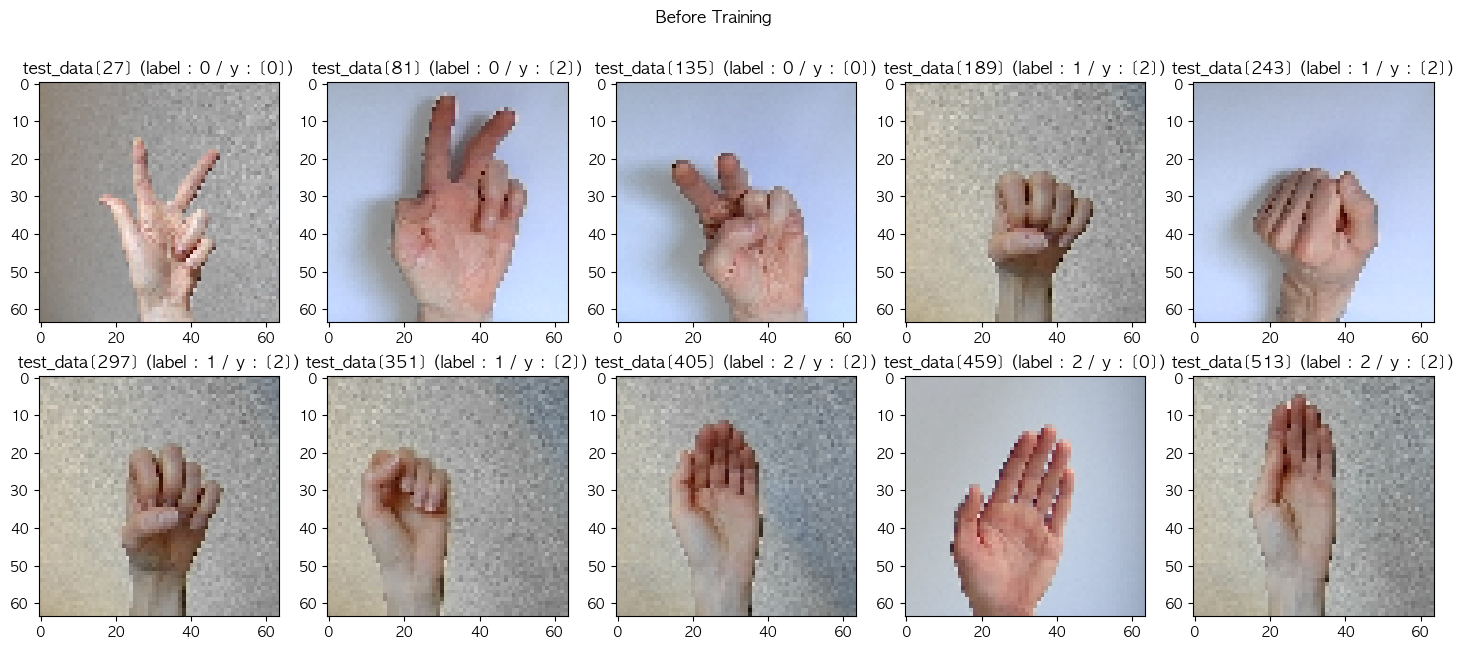

In [9]:
y_out = model.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

## 콜백 설정

In [10]:
savedModelName = 'RPS_PreTrained_DenseNet_Augmentation.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(savedModelName,
                                    save_best_only=True)
]

## 모델 학습

In [11]:
%%time
history = model.fit(train_gen, epochs=100,
                    callbacks=callbacks,
                    validation_data=(test_data, test_labels))

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 44s 345ms/step - accuracy: 0.7343 - loss: 0.6562 - val_accuracy: 0.9376 - val_loss: 0.2152
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 341ms/step - accuracy: 0.9429 - loss: 0.1647 - val_accuracy: 0.9780 - val_loss: 0.0664
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 23s 333ms/step - accuracy: 0.9576 - loss: 0.1109 - val_accuracy: 0.9908 - val_loss: 0.0276
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 321ms/step - accuracy: 0.9724 - loss: 0.0789 - val_accuracy: 0.9945 - val_loss: 0.0181
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 320ms/step - accuracy: 0.9820 - loss: 0.0618 - val_accuracy: 0.9908 - val_loss: 0.0210
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 325ms/step - accuracy: 0.9853 - loss: 0.0523 - val_accuracy: 0.9982 - val_loss: 0.0096
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 315ms/step - accuracy: 0.9862 - loss: 0.0433 - val_accuracy: 0.9890 - val_loss: 0.0235
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 316ms/step - accuracy: 0.9843 - loss: 0.0469 - 

## Ploting : Cost/Training Count

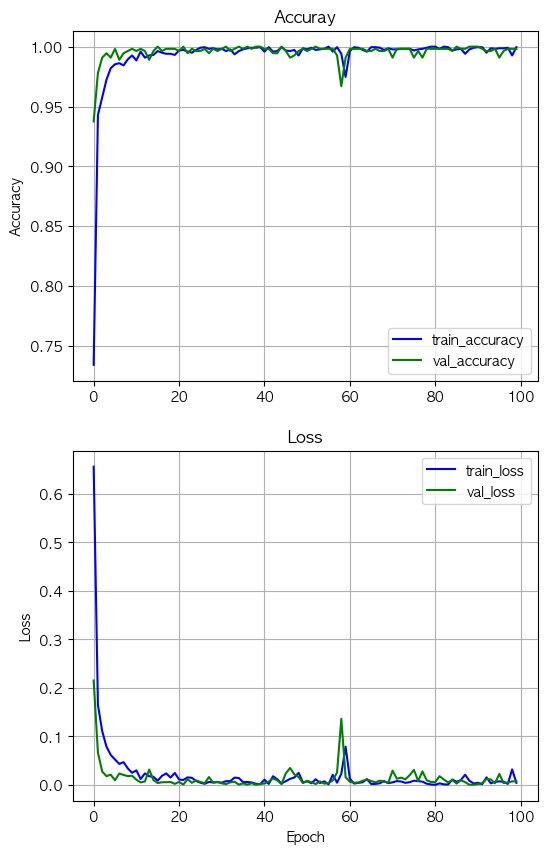

In [12]:
plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(history.history['val_accuracy'], 'g', label='val_accuracy')
# plt.ylim([0,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(history.history['loss'], 'b', label='train_loss')
plt.plot(history.history['val_loss'], 'g', label='val_loss')
# plt.ylim([0,5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

## best 모델 로딩 및 테스트

In [13]:
model_best = tf.keras.models.load_model (savedModelName)

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step


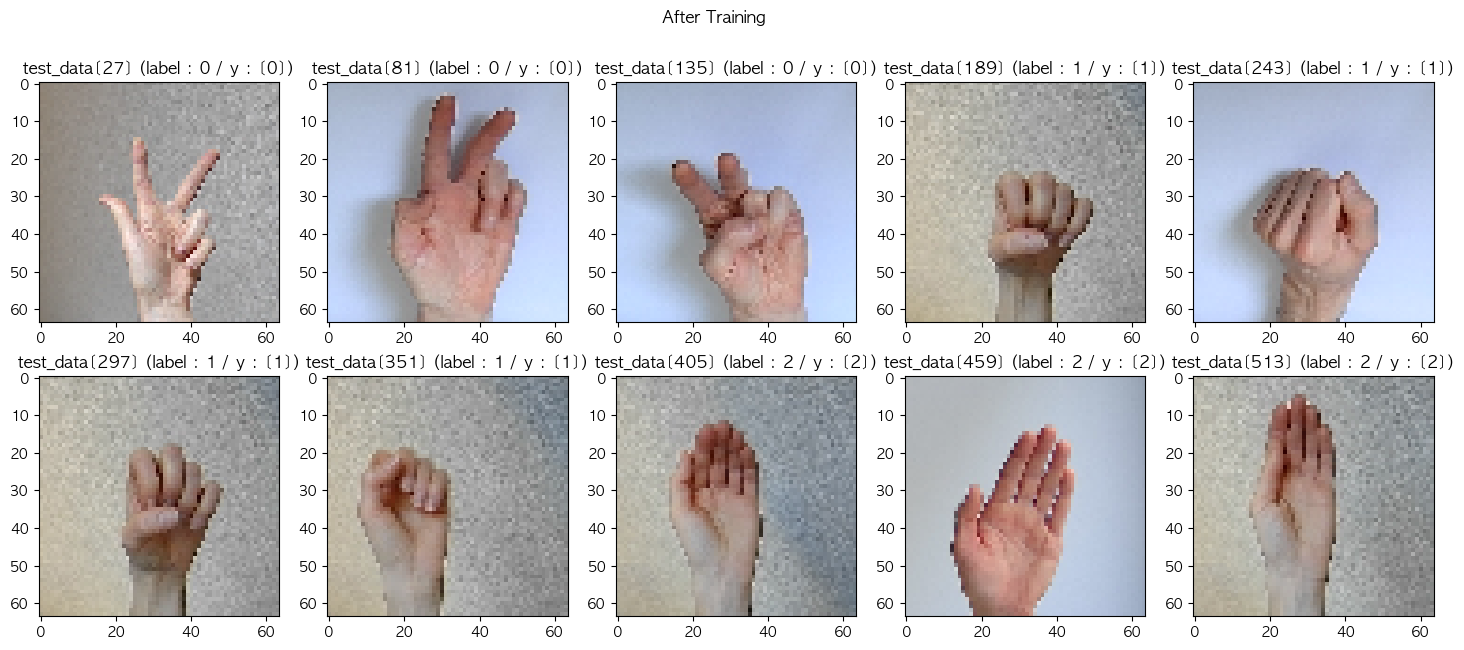

In [14]:
y_out = model_best.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)

## best 모델 백업

In [15]:
from pathlib import Path

# 현재 실행 환경이 Google Colab인지 확인합니다.
# google.colab 모듈을 import할 수 있으면 Colab 환경이고,
# import할 수 없으면 VS Code, 로컬 PC, GCUBE, Jupyter 환경으로 판단합니다.
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


# Colab에서 실행하는 경우
if IN_COLAB:
    # Google Drive를 Colab에 연결합니다.
    drive.mount('/content/drive')

    # Colab에서는 Google Drive 안에 결과를 저장합니다.
    save_dir = Path('/content/drive/MyDrive/files/save/')


# Colab이 아닌 환경에서 실행하는 경우
else:
    # VS Code, 로컬 PC, GCUBE, 일반 Jupyter에서는
    # 현재 노트북을 실행하는 폴더 아래에 files/save 폴더를 만듭니다.
    save_dir = Path('./files/save/')


# 저장 폴더가 없으면 자동으로 만듭니다.
# parents=True는 중간 폴더까지 함께 만들라는 뜻입니다.
# exist_ok=True는 이미 폴더가 있어도 오류를 내지 말라는 뜻입니다.
save_dir.mkdir(parents=True, exist_ok=True)

print("현재 실행 환경:", "Colab" if IN_COLAB else "Local / VS Code / GCUBE / Jupyter")
print("저장 폴더:", save_dir.resolve())

현재 실행 환경: Local / VS Code / GCUBE / Jupyter
저장 폴더: /Users/PhilipKim/Library/CloudStorage/OneDrive-개인/GitRP.CNN01/RP2.CNN02/examples(COLAB)/03_CNN_Based_On-Device_AI/files/save


In [16]:
from pathlib import Path

# savedModelName이 문자열(str)일 수도 있으므로 Path 객체로 변환합니다.
savedModelPath = Path(savedModelName)

# 저장 폴더와 저장 파일 확인
print("저장 폴더:", save_dir.resolve())
print("저장 모델:", savedModelPath.resolve())
print("저장 여부:", savedModelPath.exists())

저장 폴더: /Users/PhilipKim/Library/CloudStorage/OneDrive-개인/GitRP.CNN01/RP2.CNN02/examples(COLAB)/03_CNN_Based_On-Device_AI/files/save
저장 모델: /Users/PhilipKim/Library/CloudStorage/OneDrive-개인/GitRP.CNN01/RP2.CNN02/examples(COLAB)/03_CNN_Based_On-Device_AI/RPS_PreTrained_DenseNet_Augmentation.keras
저장 여부: True


In [17]:
from pathlib import Path
from datetime import datetime
import tensorflow as tf

# savedModelName이 문자열(str)이어도 Path 객체로 변환합니다.
savedModelPath = Path(savedModelName)

# 모델 파일이 실제로 존재하는지 먼저 확인합니다.
if not savedModelPath.exists():
    raise FileNotFoundError(f"모델 파일을 찾을 수 없습니다: {savedModelPath.resolve()}")

# 파일 정보 가져오기
file_stat = savedModelPath.stat()

# 생성 시간과 수정 시간 가져오기
# macOS / Windows에서는 st_birthtime이 생성 시간에 가깝습니다.
# Linux 환경에서는 st_birthtime이 없을 수 있으므로 수정 시간 기준으로 처리합니다.
try:
    created_time = datetime.fromtimestamp(file_stat.st_birthtime)
except AttributeError:
    created_time = None

modified_time = datetime.fromtimestamp(file_stat.st_mtime)

# 파일 크기 계산
file_size_mb = file_stat.st_size / (1024 * 1024)

# 모델 파일 정보 출력
print("불러올 모델 파일 정보")
print("-" * 50)
print("모델 경로:", savedModelPath.resolve())

if created_time is not None:
    print("생성 시간:", created_time.strftime("%Y-%m-%d %H:%M:%S"))
else:
    print("생성 시간: 이 환경에서는 확인 불가")

print("수정 시간:", modified_time.strftime("%Y-%m-%d %H:%M:%S"))
print("파일 크기:", f"{file_size_mb:.2f} MB")
print("-" * 50)

# 사용자에게 확인받기
answer = input("이 모델을 불러와서 TFLite로 변환할까요? 계속하려면 y를 입력하세요: ")

if answer.lower() == "y":
    # 사용자가 확인한 경우에만 best model을 불러옵니다.
    model_best = tf.keras.models.load_model(savedModelPath)

    print("Best model 불러오기 완료")

    # TFLite 변환기 생성
    converter = tf.lite.TFLiteConverter.from_keras_model(model_best)

    # TFLite 변환 실행
    tflite_model = converter.convert()

    # TFLite 저장 경로 설정
    tfliteModelName = savedModelPath.with_suffix(".tflite")

    # 변환된 TFLite 모델 저장
    with open(tfliteModelName, "wb") as f:
        f.write(tflite_model)

    print("TFLite 변환 완료")
    print("TFLite 저장 위치:", tfliteModelName.resolve())

else:
    print("작업을 취소했습니다. 모델을 불러오지 않았습니다.")

불러올 모델 파일 정보
--------------------------------------------------
모델 경로: /Users/PhilipKim/Library/CloudStorage/OneDrive-개인/GitRP.CNN01/RP2.CNN02/examples(COLAB)/03_CNN_Based_On-Device_AI/RPS_PreTrained_DenseNet_Augmentation.keras
생성 시간: 2026-05-29 23:16:44
수정 시간: 2026-05-29 23:30:41
파일 크기: 81.64 MB
--------------------------------------------------
Best model 불러오기 완료
INFO:tensorflow:Assets written to: /var/folders/h5/y9h6l_8x0d1b_hrc8y0d17rw0000gp/T/tmp7epbt5sk/assets


INFO:tensorflow:Assets written to: /var/folders/h5/y9h6l_8x0d1b_hrc8y0d17rw0000gp/T/tmp7epbt5sk/assets


Saved artifact at '/var/folders/h5/y9h6l_8x0d1b_hrc8y0d17rw0000gp/T/tmp7epbt5sk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  14916218192: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  14916218384: TensorSpec(shape=(3,), dtype=tf.float32, name=None)
  6251603984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6251603024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6251602832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6251603408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6251594576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6251594768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6251602256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6251594192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  625159380

W0000 00:00:1780066690.062127 1644957 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780066690.062259 1644957 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780066690.064879 1644957 reader.cc:83] Reading SavedModel from: /var/folders/h5/y9h6l_8x0d1b_hrc8y0d17rw0000gp/T/tmp7epbt5sk
I0000 00:00:1780066690.075635 1644957 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780066690.075643 1644957 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/h5/y9h6l_8x0d1b_hrc8y0d17rw0000gp/T/tmp7epbt5sk
I0000 00:00:1780066690.209576 1644957 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1780066690.233695 1644957 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1780066690.992284 1644957 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/h5/y9h6l_8x0d1b_hrc8y0d17rw0000gp/T/tmp7epbt5sk
I0000 00:00:1780066691.210716 1644957 lo

## LiteRT 모델을 파일로 저장

In [18]:
from pathlib import Path
from datetime import datetime

# 비교할 파일 경로 설정
# savedModelName이 이미 .keras 파일 경로라면 그대로 사용합니다.
keras_path = Path(savedModelName)

# .keras 파일과 같은 이름의 .tflite 파일 경로를 만듭니다.
# 예: RPS_PreTrained_DenseNet.keras → RPS_PreTrained_DenseNet.tflite
tflite_path = keras_path.with_suffix(".tflite")


# 파일 정보를 보기 좋게 출력하는 함수
def print_file_info(title, file_path):
    file_path = Path(file_path)

    print(f"\n[{title}]")

    if not file_path.exists():
        print("파일 없음:", file_path.resolve())
        return None

    stat = file_path.stat()

    # 파일 크기
    size_mb = stat.st_size / (1024 * 1024)

    # 수정 시간
    modified_time = datetime.fromtimestamp(stat.st_mtime)

    # 생성 시간
    # macOS / Windows에서는 st_birthtime이 있을 수 있습니다.
    # Linux / Colab / 일부 서버에서는 없을 수 있습니다.
    try:
        created_time = datetime.fromtimestamp(stat.st_birthtime)
        created_text = created_time.strftime("%Y-%m-%d %H:%M:%S")
    except AttributeError:
        created_text = "이 환경에서는 생성 시간 확인 불가"

    print("파일 경로:", file_path.resolve())
    print("파일 크기:", f"{size_mb:.2f} MB")
    print("생성 시간:", created_text)
    print("수정 시간:", modified_time.strftime("%Y-%m-%d %H:%M:%S"))

    return size_mb


# Before: Keras 모델 정보
keras_size = print_file_info("Before: Keras 모델", keras_path)

# After: TFLite 모델 정보
tflite_size = print_file_info("After: TFLite 모델", tflite_path)


# 크기 감소율 계산
if keras_size is not None and tflite_size is not None:
    reduction = (1 - tflite_size / keras_size) * 100

    print("\n[크기 비교 결과]")
    print("Keras 모델 크기:", f"{keras_size:.2f} MB")
    print("TFLite 모델 크기:", f"{tflite_size:.2f} MB")
    print("크기 감소율:", f"{reduction:.2f}%")


[Before: Keras 모델]
파일 경로: /Users/PhilipKim/Library/CloudStorage/OneDrive-개인/GitRP.CNN01/RP2.CNN02/examples(COLAB)/03_CNN_Based_On-Device_AI/RPS_PreTrained_DenseNet_Augmentation.keras
파일 크기: 81.64 MB
생성 시간: 2026-05-29 23:16:44
수정 시간: 2026-05-29 23:30:41

[After: TFLite 모델]
파일 경로: /Users/PhilipKim/Library/CloudStorage/OneDrive-개인/GitRP.CNN01/RP2.CNN02/examples(COLAB)/03_CNN_Based_On-Device_AI/RPS_PreTrained_DenseNet_Augmentation.tflite
파일 크기: 26.64 MB
생성 시간: 2026-05-29 23:58:12
수정 시간: 2026-05-29 23:58:12

[크기 비교 결과]
Keras 모델 크기: 81.64 MB
TFLite 모델 크기: 26.64 MB
크기 감소율: 67.37%
